### Librerias


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import folium
import io
import base64

### Carga de datos

In [2]:
df = pd.read_csv(r"..\..\Data\clean_data_09-03-2026.csv",parse_dates=['insert_date','first_review_date','last_review_date'])

In [3]:
df.head(5)

,apartment_id,room_type,price,has_availability,availability_30,availability_60,availability_90,availability_365,review_scores_rating,first_review_date,last_review_date,number_of_reviews,reviews_per_month,city,insert_date,reviews 80+
0,11964,Private room,400.0,True,7,20,40,130,97.0,2010-01-02,2017-09-05,78,0.76,Malaga,2018-07-31,True
1,21853,Private room,170.0,True,0,0,0,162,92.0,2014-10-10,2018-07-15,33,0.52,Madrid,2020-01-10,True
2,32347,Entire home/apt,990.0,True,26,31,31,270,98.0,2011-01-05,2019-07-22,148,1.44,Sevilla,2019-07-29,True
3,35379,Private room,400.0,True,9,23,49,300,94.0,2012-03-13,2020-01-04,292,3.10,Barcelona,2020-01-10,True
4,35801,Private room,900.0,True,0,19,49,312,97.0,2011-07-08,2018-08-08,36,0.39,Girona,2019-02-19,True


### Análisis / visualizaciones

Quin és el preu mitjà dels allotjaments per tipus d'allotjament a cada ciutat?


Estudio descriptivo inicial para entender el punto de partida: comparativa de precios medios y distribución de volumen según el tipo de habitación y la ciudad

In [4]:
mediageneral=df['price'].mean().round(2)

mediageneral

np.float64(1011.0)

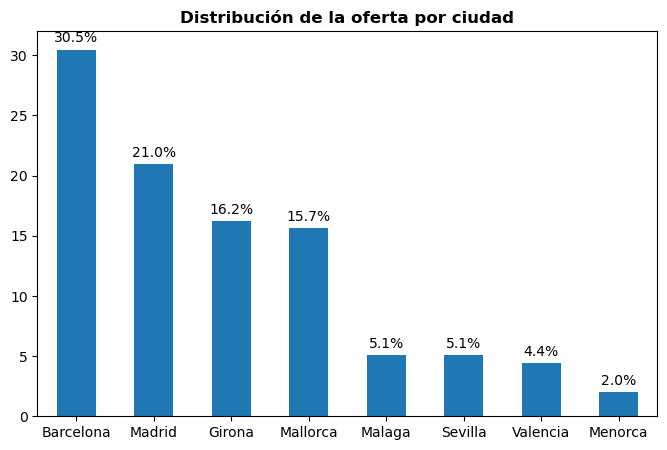

In [5]:
datos_porcentajes_city = df['city'].value_counts(normalize=True) * 100

ax = datos_porcentajes_city.plot.bar(figsize=(8, 5), color='#1f77b4')


ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=3)


plt.title('Distribución de la oferta por ciudad', fontweight='bold')
plt.xlabel('') 
plt.xticks(rotation=0) 

plt.show()

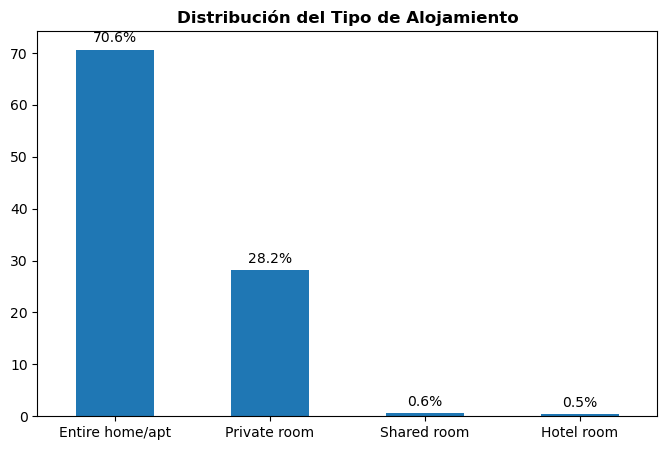

In [6]:

datos_porcentajes_room = df['room_type'].value_counts(normalize=True) * 100


ax = datos_porcentajes_room.plot.bar(figsize=(8, 5), color='#1f77b4')


ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=3)


plt.title('Distribución del Tipo de Alojamiento', fontweight='bold')
plt.xlabel('') 
plt.xticks(rotation=0) 

plt.show()

In [7]:
df.groupby('room_type')[['price']].mean().round(2)

,price
room_type,
Entire home/apt,1241.61
Hotel room,1063.03
Private room,448.24
Shared room,324.15


<Axes: xlabel='room_type'>

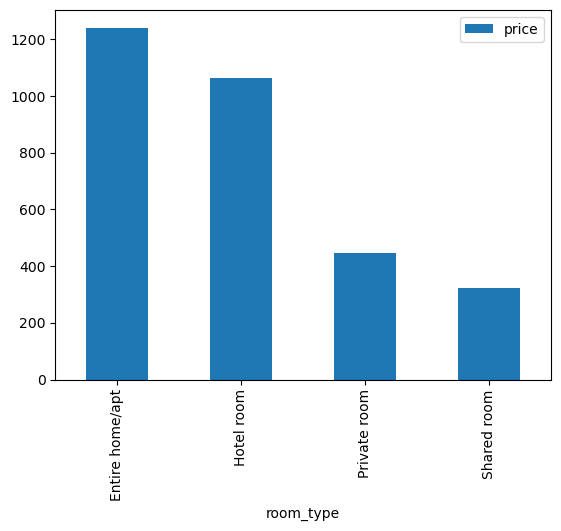

In [8]:
df.groupby('room_type')[['price']].mean().sort_values(by='price',ascending=False).plot.bar()

Comparativa global de medias y mediana

In [9]:
df_mean = df.groupby('room_type')['price'].mean().reset_index()


media_total = df['price'].mean()
mediana_total = df['price'].median()


fig = px.bar(df_mean, x='room_type', y='price', 
             title="Precio por Tipo de Habitación vs Métricas Globales",
             labels={'price': 'Precio ($)', 'room_type': 'Tipo de Habitación'})


fig.add_hline(y=media_total, 
              line_dash="dot", 
              line_color="red",
              annotation_text=f"Media: {media_total:.2f}", 
              annotation_position="top left")


fig.add_hline(y=mediana_total, 
              line_dash="dash", 
              line_color="green",
              annotation_text=f"Mediana: {mediana_total:.2f}", 
              annotation_position="bottom left")

fig.show()

In [10]:
df.groupby(['city'])['price'].mean().round(2).reset_index()

,city,price
0,Barcelona,847.89
1,Girona,1198.50
2,Madrid,740.83
3,Malaga,733.69
4,Mallorca,1627.30
5,Menorca,1578.43
6,Sevilla,940.47
7,Valencia,690.73


<Axes: xlabel='city'>

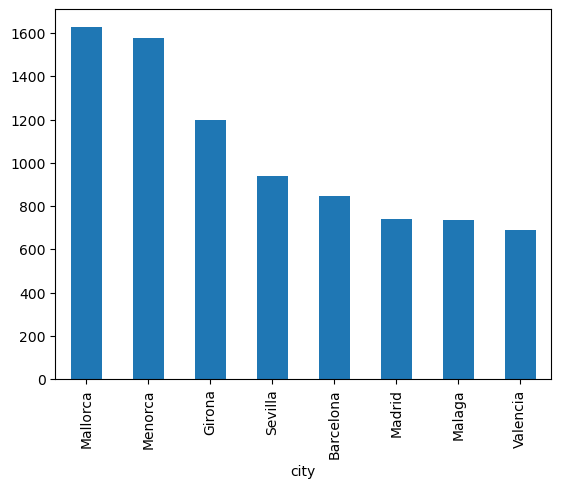

In [11]:
df.groupby(['city'])['price'].mean().sort_values(ascending=False).plot.bar()

Concentración del Inventario:
 Se observa una fuerte polarización territorial en nuestro mercado. Apenas 4 ciudades aglutinan aproximadamente el 80% de la oferta total, constituyendo nuestro mercado principal.

Dominancia del Alojamiento Completo: 
El mix de producto está claramente definido. El formato "Apartamento/Casa entera" es el producto estrella (70.6%), seguido de la "Habitación privada" (28.2%). Las opciones de "Habitación de Hotel" (0.5%) y "Habitación Compartida" (0.6%) tienen una presencia puramente residual.

Bifurcación del Ticket Medio:
 Las medianas de precio revelan una brecha muy marcada entre dos segmentos de cliente. Existe un segmento Premium/Privacidad muy superior en precio (Casa entera: 1.241€ | Hotel: 1.063€) y un segmento Económico mucho más accesible (Habitación privada: 448€ | Compartida: 324€).

## Desglose Estratégico: Cruce de Precios, Producto y Ciudad

In [12]:

orden_ciudades_global = df['city'].value_counts().index.tolist()


top_4_ciudades = orden_ciudades_global[:4]  
bottom_4_ciudades = orden_ciudades_global[4:] 

print("Top 4 (Mercados Principales):", top_4_ciudades)
print("Bottom 4 (Mercados Secundarios):", bottom_4_ciudades)

Top 4 (Mercados Principales): ['Barcelona', 'Madrid', 'Girona', 'Mallorca']
Bottom 4 (Mercados Secundarios): ['Malaga', 'Sevilla', 'Valencia', 'Menorca']


In [13]:


rangos = [0, 500, 1000, 2000, float('inf')]
labels = ['Económico', 'Medio', 'Caro', 'Lujo']
df['price_range'] = pd.cut(df['price'], bins=rangos, labels=labels)

# 2. Definir las columnas que queremos conectar
# Flujo 1: City -> Room Type
# Flujo 2: Room Type -> Price Range
def genSankey(df, cat_cols=[], value_col=''):
    label_list = []
    for col in cat_cols:
        label_list.extend(list(df[col].unique()))
    label_list = list(dict.fromkeys(label_list)) # Eliminar duplicados
    
    source = []
    target = []
    values = []
    
    for i in range(len(cat_cols)-1):
        group = df.groupby([cat_cols[i], cat_cols[i+1]],observed=True)[value_col].count().reset_index()
        for _, row in group.iterrows():
            source.append(label_list.index(row[cat_cols[i]]))
            target.append(label_list.index(row[cat_cols[i+1]]))
            values.append(row[value_col])
            
    return label_list, source, target, values


label, source, target, value = genSankey(df, ['city', 'room_type', 'price_range'], 'apartment_id')

fig = go.Figure(data=[go.Sankey(
    node = dict(pad = 15, thickness = 20, line = dict(color = "black", width = 0.5), label = label),
    link = dict(source = source, target = target, value = value)
)])

fig.update_layout(title_text="Flujo de Ciudad - Alojamientos - Precio", font_size=12)
fig.show()

Comparativa de la media de precios por Room type por ciudad

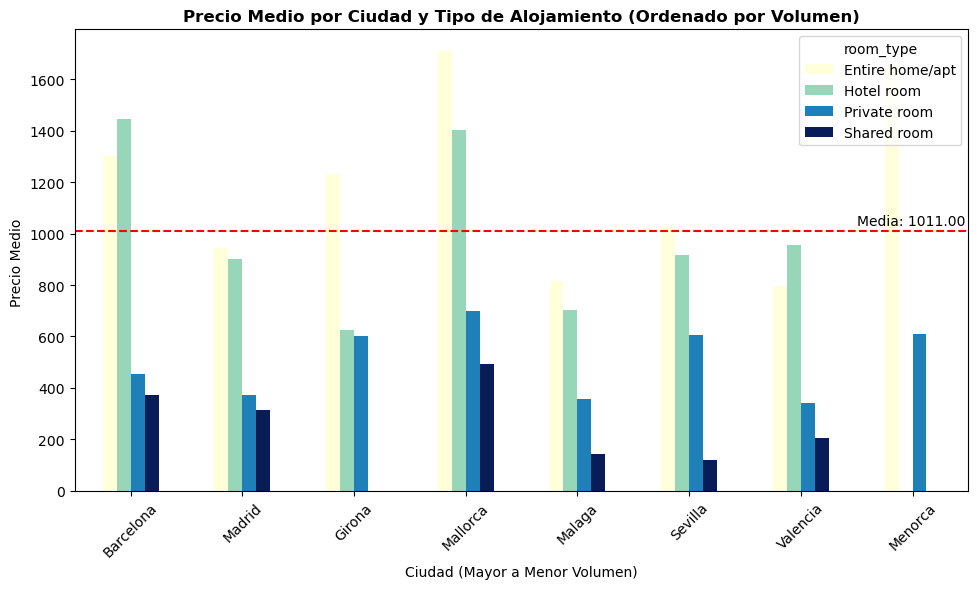

In [14]:

orden_ciudades = df['city'].value_counts().index.tolist()

room_pivot = df.pivot_table(index='city', columns='room_type', values='price', aggfunc='mean',observed=False)


room_pivot = room_pivot.reindex(orden_ciudades)


room_pivot.plot.bar(figsize=(10, 6), colormap='YlGnBu')

media_global = df['price'].mean()
plt.axhline(media_global, color='red', linestyle='--', linewidth=1.5, label=f'Media Global ({media_global:.2f})')


plt.text(
    x = len(orden_ciudades) - 1.5,   
    y = media_global + 10,           
    s = f'Media: {media_global:.2f}', 
    color = 'black',              
    va = 'bottom'                 
)


plt.title('Precio Medio por Ciudad y Tipo de Alojamiento (Ordenado por Volumen)', fontweight='bold')
plt.xlabel('Ciudad (Mayor a Menor Volumen)')
plt.ylabel('Precio Medio ')
plt.xticks(rotation=45) 

plt.tight_layout() 
plt.show()

<module 'matplotlib.pyplot' from 'c:\\ProgramData\\anaconda3\\Lib\\site-packages\\matplotlib\\pyplot.py'>

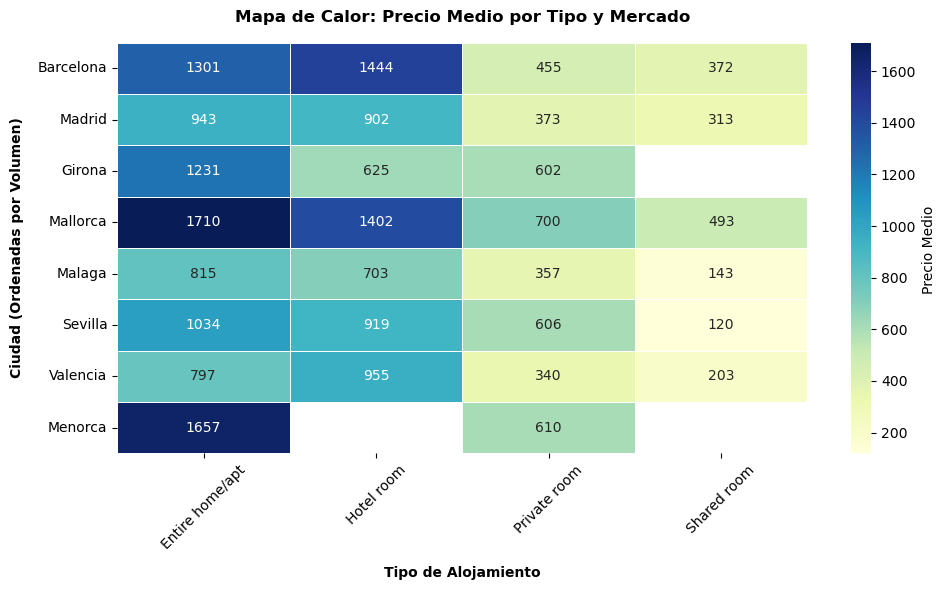

In [15]:


orden_ciudades = df['city'].value_counts().index.tolist()
room_pivot = df.pivot_table(index='city', columns='room_type', values='price', aggfunc='mean',observed=True)
room_pivot = room_pivot.reindex(orden_ciudades)


plt.figure(figsize=(10, 6))


sns.heatmap(
    room_pivot, 
    annot=True, 
    fmt=".0f", 
    cmap="YlGnBu", 
    linewidths=0.5, 
   
    cbar_kws={'label': 'Precio Medio '}
)


plt.xlabel("Tipo de Alojamiento", fontweight='bold', labelpad=10)
plt.ylabel("Ciudad (Ordenadas por Volumen)", fontweight='bold', labelpad=10)
plt.title("Mapa de Calor: Precio Medio por Tipo y Mercado", fontweight='bold', pad=15)


plt.xticks(rotation=45) 

plt.tight_layout()
plt

Brecha de Volumen : 
El diagrama de flujo evidencia una fuerte asimetría en nuestra cuota de mercado. La oferta está fuertemente capitalizada por el "Top 4" (Barcelona, Madrid, Girona y Mallorca). Esto nos obliga a segmentar el análisis a partir de este punto para no aplicar estrategias de masas en mercados que realmente son de nicho.

El Mapa de Rentabilidad:
 El producto Entire home/apt no solo lidera en volumen, sino que concentra los tickets medios más altos junto con la categoría hotelera. Las habitaciones privadas actúan como el producto refugio/económico que sostiene la demanda de menor presupuesto.

Anomalías "Premium" :
 El mapa de calor y el gráfico de barras revelan que Mallorca y Menorca operan bajo sus propias reglas. A pesar de que Menorca tiene el menor volumen de la red, sus precios medios compiten directamente con los de Mallorca (ambos superando los 1.600€ en casas enteras). Son mercados puramente vacacionales de alto margen.

Huecos de Oferta (Oportunidades de Expansión):
 El mapa de calor muestra nichos completamente vacíos (ej. nula oferta de hoteles o habitaciones compartidas en Girona y Menorca). Estos "espacios en blanco" representan oportunidades directas para futuras campañas de captación B2B.


#  Mercados Principales (High Volume): Concentración y Competencia.

In [16]:

colores_corporativos = {
    'Entire home/apt': '#FFFFE0',  
    'Hotel room': '#A1D9B5',       
    'Private room': '#1F78B4',     
    'Shared room': '#08306B'       
}

In [17]:


dftop4=df[df['city'].isin(top_4_ciudades)].copy()

agrupado=dftop4.groupby(['city','room_type'])['price'].mean().round(2).reset_index()

Text(0.5, 1.05, 'Precio Medio por Tipo de Habitación en cada Ciudad')

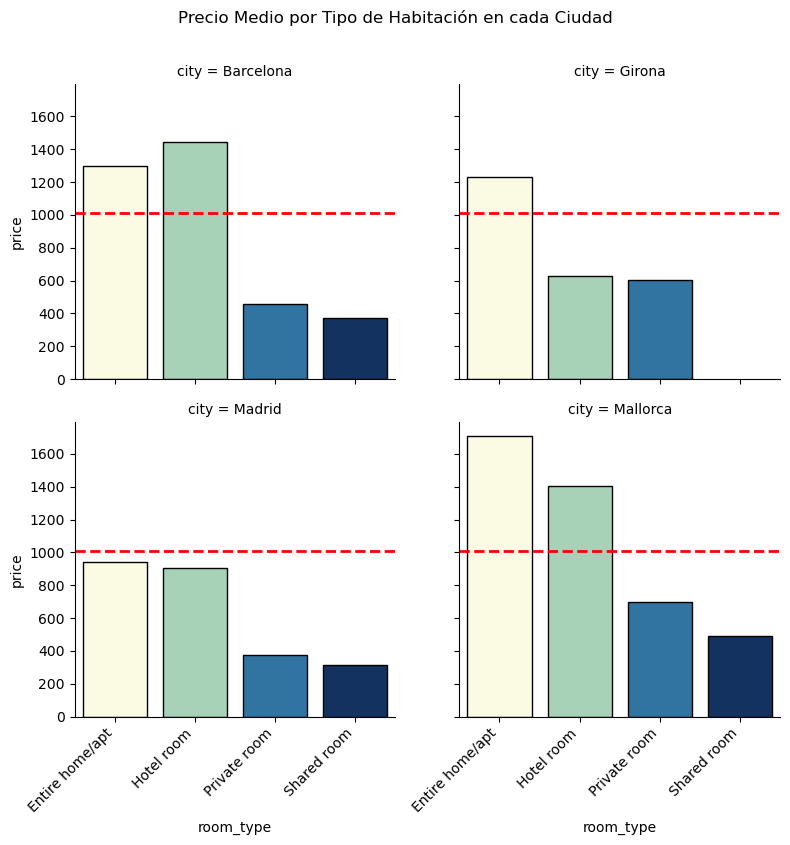

In [18]:

g=sns.catplot(
    data=agrupado, 
    x='room_type', 
    y='price', 
    col='city',      
    kind='bar',      
    col_wrap=2,      
    height=4,       
    palette=colores_corporativos,
    edgecolor='black',
    hue='room_type',
    legend=False 
)

for ax in g.axes.flat:
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')


plt.tight_layout()
g.refline(y=mediageneral, color='red', linestyle='--', linewidth=2)
plt.suptitle('Precio Medio por Tipo de Habitación en cada Ciudad', y=1.05)
 

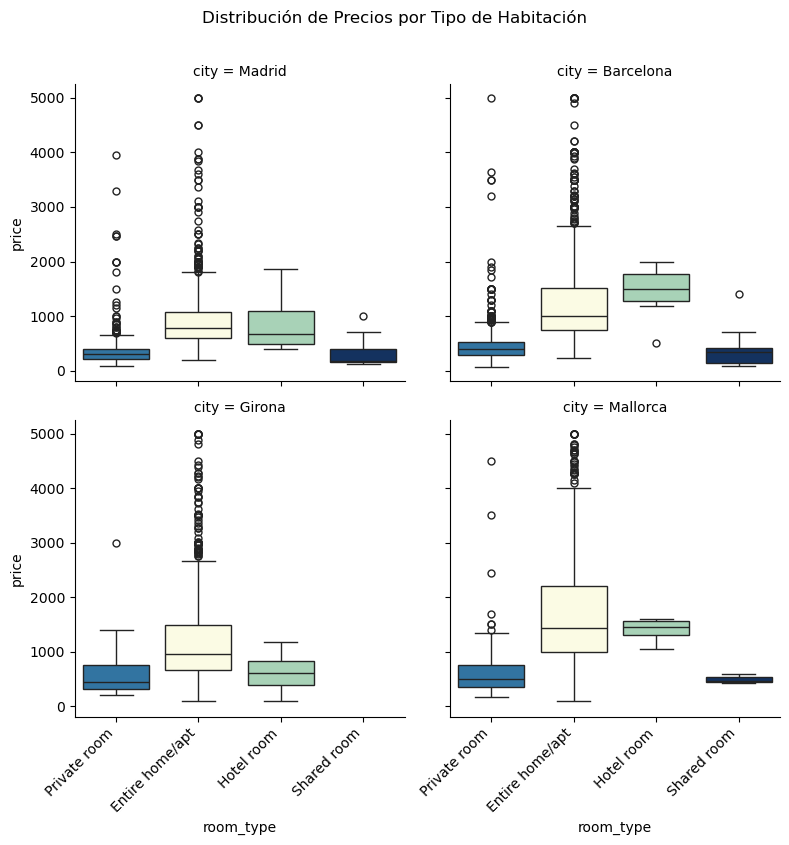

In [19]:

g2=sns.catplot(
    data=dftop4,  
    x='room_type', 
    y='price', 
    col='city',      
    kind='box',       
    col_wrap=2,      
    height=4,        
    palette=colores_corporativos,
    hue='room_type',
    legend=False 
)

for ax in g2.axes.flat:
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')


plt.tight_layout()
plt.suptitle('Distribución de Precios por Tipo de Habitación', y=1.05)
plt.show()

In [20]:
cuentadetipostop4=dftop4.groupby(['city'],observed=True)['room_type'].value_counts().reset_index()
cuentadetipostop4normalizado=dftop4.groupby(['city'],observed=True)['room_type'].value_counts(normalize=True).reset_index(name='porcentaje')
cuentadetipostop4normalizado['porcentaje'] = cuentadetipostop4normalizado['porcentaje'] * 100

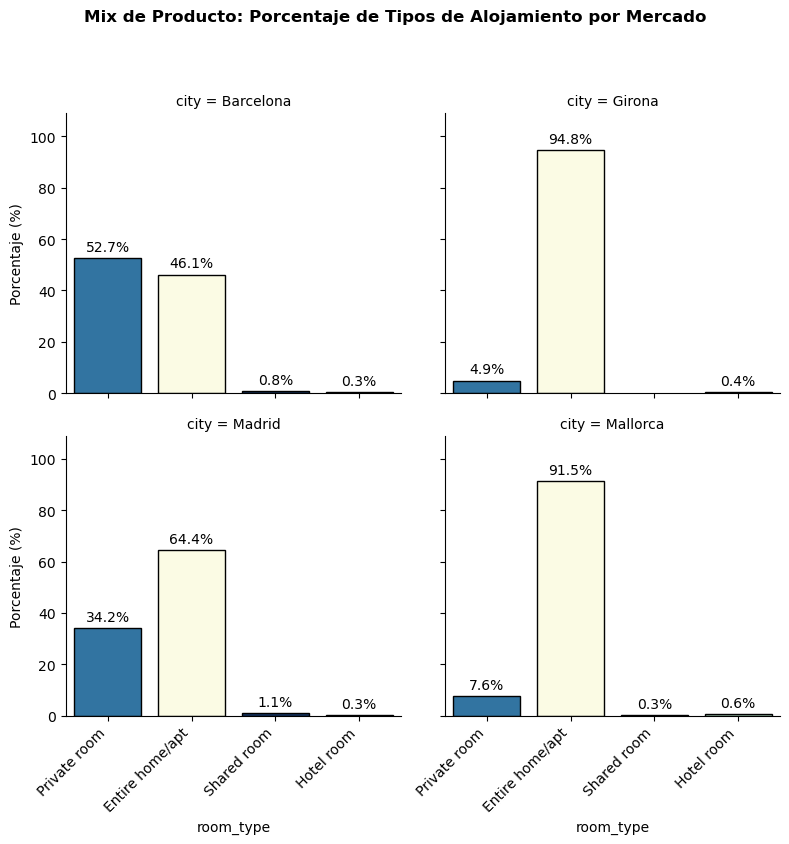

In [21]:

g = sns.catplot(
    data=cuentadetipostop4normalizado, 
    x='room_type', 
    y='porcentaje',  
    col='city',      
    kind='bar',      
    col_wrap=2,      
    height=4,       
    palette=colores_corporativos,
    edgecolor='black',
    hue='room_type', 
    legend=False
)

plt.suptitle('Mix de Producto: Porcentaje de Tipos de Alojamiento por Mercado', y=1.05, fontweight='bold')


for ax in g.axes.flat:
    ax.set_ylabel('Porcentaje (%)')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    

    
    for container in ax.containers:
       
        ax.bar_label(container, fmt='%.1f%%', padding=3, size=10)
    

    ax.margins(y=0.15)
  

plt.tight_layout()
plt.show()

Comportamiento de los Mercados Principales (Top 4)
El análisis cruzado del Mix de Producto y la Distribución de Precios en nuestros cuatro mercados de mayor volumen revela dos realidades comerciales muy diferenciadas:

El Modelo Vacacional (Mallorca y Girona): Su mix de producto es monolítico. Más del 90% de su inventario son casas o apartamentos enteros. Los gráficos de caja (boxplots) de estas ciudades muestran una enorme dispersión hacia arriba (outliers que llegan a los 5.000€). Insight estratégico: Estos mercados no compiten en volumen de reservas diarias, sino en margen de beneficio por reserva. Son el escenario perfecto para lanzar campañas de producto "Premium/Villas", ignorando por completo la comercialización de habitaciones privadas.

El Modelo Urbano/Regulatorio (Barcelona y Madrid): Aquí el inventario está mucho más fragmentado. Llama la atención el caso de Barcelona, donde la "Habitación Privada" (52.7%) supera al "Apartamento Entero", una anomalía probablemente impulsada por las estrictas regulaciones municipales sobre licencias turísticas. Insight estratégico: En estos mercados, nuestra estrategia de marketing debe ser dual: captación masiva para el público joven/budget (habitaciones) y optimización de tarifas dinámicas para los apartamentos enteros, ya que al ser más escasos, tienen un gran poder de fijación de precios.

Barcelona y Mallorca como "Cash Cows" (Generadores de Caja): Al observar el gráfico de barras respecto a la línea roja (media global de 1.011€), queda claro que Barcelona y Mallorca son los motores de rentabilidad. Sus productos estrella (Apartamentos y Hoteles) se sitúan sistemáticamente por encima de la media de la red.

La Consistencia del Sector Hotelero: En el gráfico de cajas de Barcelona, la categoría "Hotel room" presenta una caja muy compacta y elevada, sin tantos outliers como los apartamentos. Esto indica que la oferta hotelera mantiene precios altos y estables, lo que nos da una pista clara: nuestros apartamentos enteros en Barcelona tienen margen para subir el precio base sin dejar de ser competitivos frente a los hoteles.

## Mercados Secundarios (Low Volume): Oportunidades de Expansión.

In [22]:
df_bottom4 = df[df['city'].isin(bottom_4_ciudades)].copy()

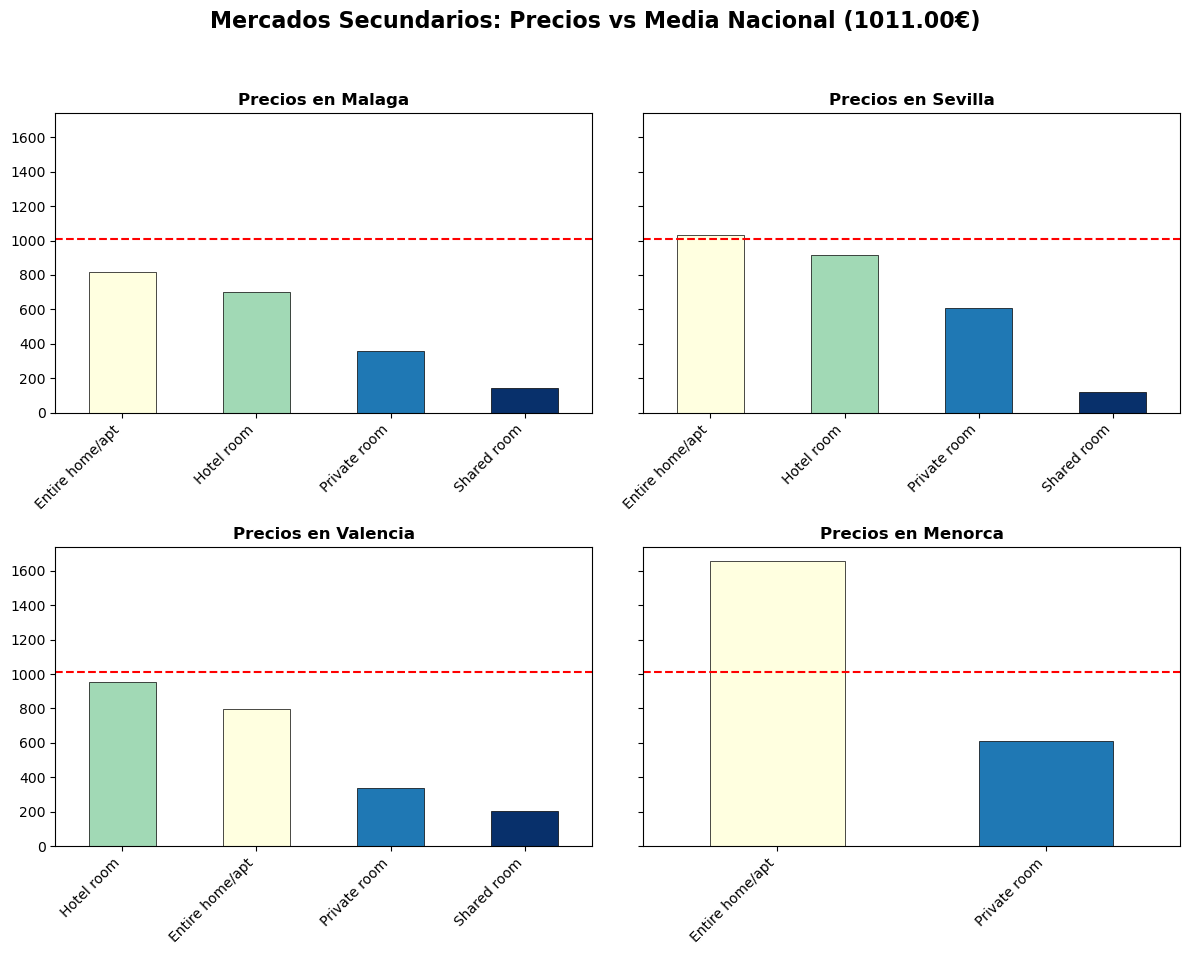

In [23]:



ciudades_secundarias = bottom_4_ciudades 

media_global = df['price'].mean()





fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharey=True)
axes = axes.flatten()

for i, ciudad in enumerate(ciudades_secundarias):
    
    stats_ciudad = df_bottom4[df_bottom4['city'] == ciudad].groupby('room_type', observed=True)['price'].mean().sort_values(ascending=False)
    
    
    stats_ciudad.plot.bar(
        ax=axes[i], 
        color=[colores_corporativos.get(tipo) for tipo in stats_ciudad.index], 
        edgecolor='black', 
        linewidth=0.5
    )
    
    
    axes[i].axhline(media_global, color='red', linestyle='--', linewidth=1.5, label='Media Global')
    
    axes[i].set_title(f'Precios en {ciudad}', fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)
    
    
    for label in axes[i].get_xticklabels():
        label.set_ha('right')


plt.suptitle(f'Mercados Secundarios: Precios vs Media Nacional ({media_global:.2f}€)', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

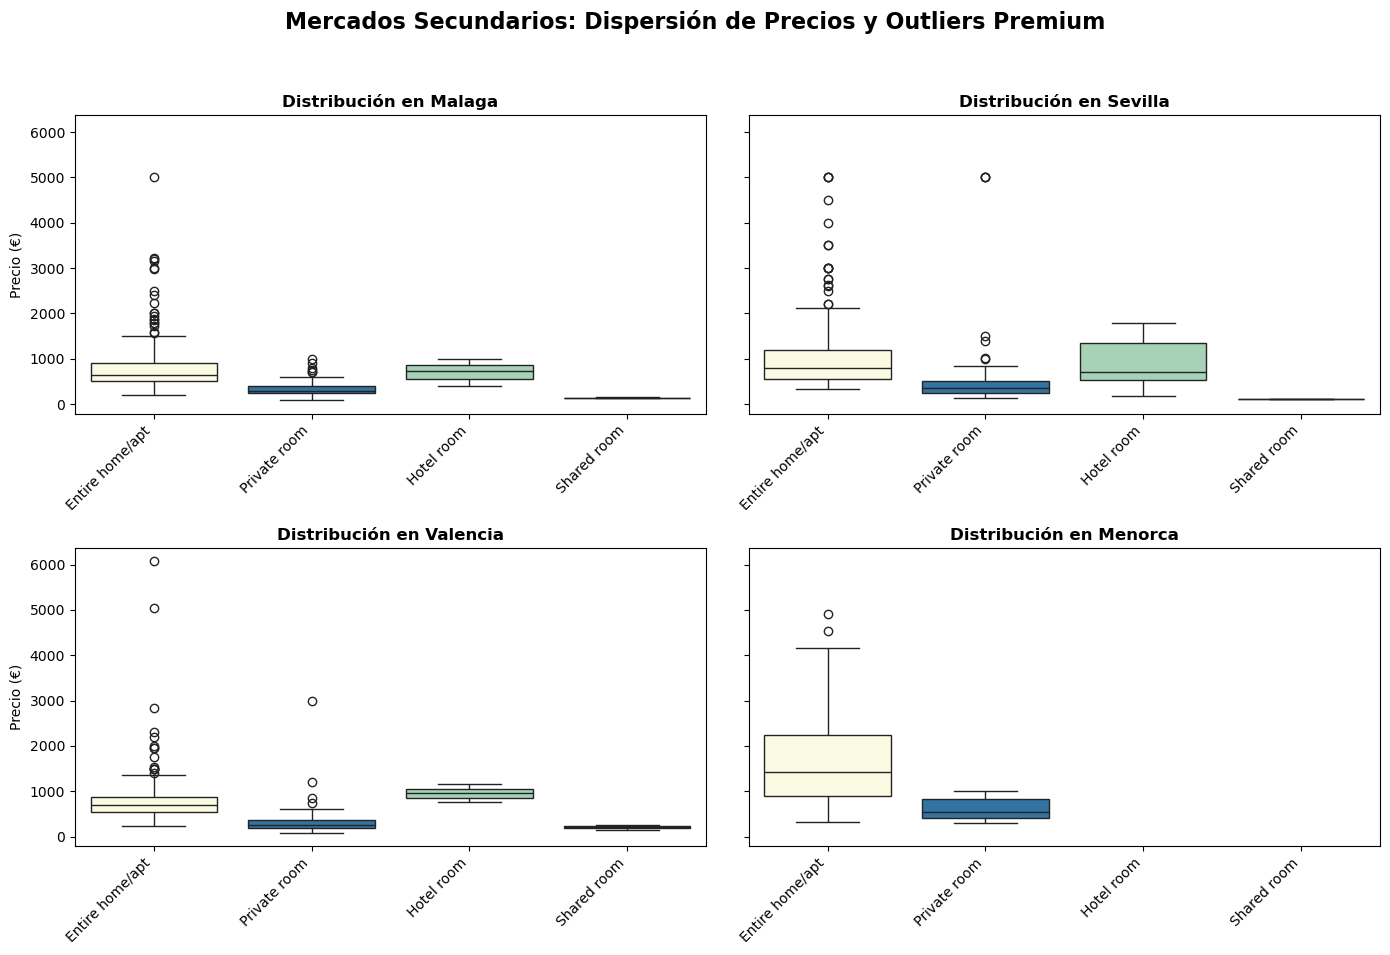

In [24]:

ciudades_secundarias = bottom_4_ciudades


fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
axes = axes.flatten()

for i, ciudad in enumerate(ciudades_secundarias):
   
    df_city = df_bottom4[df_bottom4['city'] == ciudad]
    
    
    sns.boxplot(
        data=df_city, 
        x='room_type', 
        y='price', 
        ax=axes[i],
        palette=colores_corporativos, 
        hue='room_type',            
        legend=False,
        order=['Entire home/apt', 'Private room', 'Hotel room', 'Shared room'] 
    )
    
    axes[i].set_title(f'Distribución en {ciudad}', fontweight='bold')
    axes[i].set_xlabel('')
    
    
    axes[i].tick_params(axis='x', rotation=45)
    for label in axes[i].get_xticklabels():
        label.set_ha('right')
        
    
    if i % 2 == 0: 
        axes[i].set_ylabel('Precio (€)') 


plt.suptitle('Mercados Secundarios: Dispersión de Precios y Outliers Premium', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

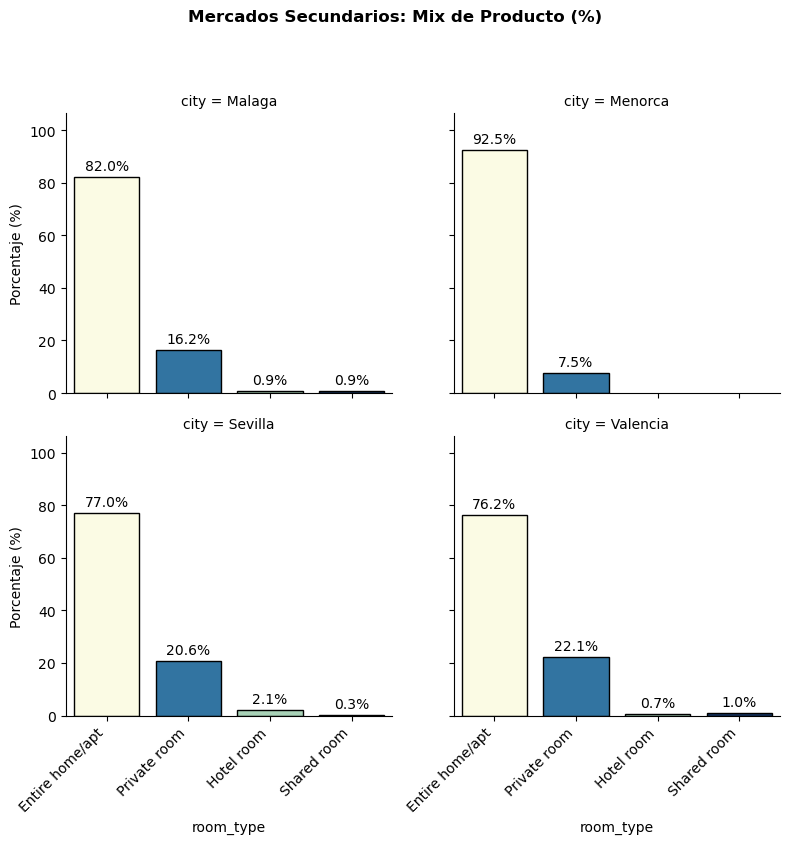

In [25]:
cuentadetipos_bot = df_bottom4.groupby(['city'], observed=True)['room_type'].value_counts(normalize=True).reset_index(name='porcentaje')
cuentadetipos_bot['porcentaje'] = cuentadetipos_bot['porcentaje'] * 100

g3 = sns.catplot(
    data=cuentadetipos_bot,
    x='room_type',
    y='porcentaje',
    col='city',
    kind='bar',
    col_wrap=2,
    height=4,
    palette=colores_corporativos,
    edgecolor='black',
    hue='room_type',
    legend=False
)
plt.suptitle('Mercados Secundarios: Mix de Producto (%)', y=1.05, fontweight='bold')

for ax in g3.axes.flat:
    ax.set_ylabel('Porcentaje (%)')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', padding=3, size=10)
    ax.margins(y=0.15)

plt.tight_layout()
plt.show()

Al analizar la segunda mitad de nuestro portfolio, los datos nos cuentan una historia de oportunidades muy clara:

Menorca es una "Falsa Secundaria": Aunque tiene el menor volumen de nuestra red, sus precios la colocan en la liga de los grandes. Es la única ciudad de este grupo que rompe la media nacional (línea roja), superando los 1.600€ de media en apartamentos enteros. Los outliers de su boxplot rozan los 5.000€, confirmando que es un nicho de ultra-lujo, no un mercado de masas.

El Triángulo de Accesibilidad (Málaga, Sevilla, Valencia): Estas tres ciudades se comportan casi como clones. Precios muy estables (por debajo de la media nacional) y boxplots muy compactos. Son mercados muy maduros y predecibles, ideales para asegurar ingresos constantes y atraer al viajero de presupuesto medio.

Monopolio del Apartamento Entero: El mix de producto revela que el "Entire home/apt" es el rey absoluto, representando entre el 76% y el 92.5% de la oferta. Las opciones de "Hotel" o "Shared room" son estadísticamente irrelevantes en estas plazas (menos del 2%).

###  Conclusiones Generales



Si alejamos la lupa y miramos las 8 ciudades en conjunto, estas son las verdades de nuestro negocio:

Dicotomía de Negocio: No somos una plataforma con una estrategia única. Operamos dos negocios distintos bajo el mismo techo: un modelo de alto volumen/ticket mixto en grandes urbes (Barcelona/Madrid) y un modelo vacacional High-Ticket en las islas (Mallorca/Menorca).

Riesgo de Concentración: Nuestra dependencia del "Apartamento Entero" es masiva a nivel global. Esto nos hace muy fuertes en ingresos, pero vulnerables a cambios en las regulaciones de licencias turísticas (especialmente en ciudades como Barcelona o Valencia).

El Agujero Hotelero: A excepción de una leve presencia en Madrid y Barcelona, la categoría "Hotel room" es un desierto en nuestra red, lo que representa un mercado gigante sin explotar.

Propuestas de Negocio Estratégicas

1. Expansión B2B Hotelera (Tu idea de aliarse con hoteles)

El Dato: El mix de producto muestra que los hoteles representan un 0% - 2% en 6 de nuestras 8 ciudades.

La Propuesta: Lanzar una línea de negocio B2B para captar hoteles boutique independientes. Ofrecerles nuestra plataforma como canal de distribución premium con comisiones reducidas el primer año para llenar ese enorme "hueco" en blanco de nuestros gráficos.

2. Creación de la Categoría "Private Room Premium" 

El Dato: La habitación privada tiene entre un 16% y un 22% de cuota en ciudades como Sevilla o Valencia, pero su precio está estancado muy abajo.

La Propuesta: Al no haber casi hoteles, la gente que busca "algo mejor que una habitación estándar pero sin pagar un piso entero" no tiene opciones. Crear un sello "Premium" para habitaciones privadas que incluyan baño propio o amenities de hotel nos permitirá subir el precio medio sin necesidad de captar más apartamentos.

3. Programa "High-Ticket Loyalty" 

El Dato: Los apartamentos enteros sostienen financieramente la plataforma (son el 80% de la oferta y los tickets más altos).

La Propuesta: Cuesta mucho más captar a un cliente dispuesto a pagar 1.500€ por una semana que a un mochilero. Implementar un programa de fidelización exclusivo para reservas de casas enteras. Si repiten año tras año, ofrecer early check-ins, late check-outs gratuitos o detalles de bienvenida. Esto asegura nuestro margen principal.

4. Tarifas Dinámicas para "Nómadas Digitales" 

El Dato: Málaga, Valencia y Sevilla tienen precios muy por debajo de la media global y son ciudades muy atractivas para extranjeros.

La Propuesta: Fomentar el alquiler de media estancia (1-3 meses) en temporada baja en estas ciudades concretas, ofreciendo descuentos automáticos por estancias largas para mantener la ocupación al 100% todo el año.
5. Diversificación Geográfica Estratégica (Expansión Norte e Interior)

El Dato: El mapeo actual de nuestra oferta revela una altísima concentración en el arco mediterráneo, las islas y Andalucía. A excepción del mercado urbano de Madrid, el interior de la Península y toda la franja norte de España representan un punto ciego total en nuestra cuota de mercado.

La Propuesta: Diseñar una fase de captación enfocada en mercados de la zona norte (ej. País Vasco, Cantabria, Galicia) y ciudades clave de interior. Esta diversificación nos permitirá desestacionalizar los ingresos (rompiendo la dependencia del turismo de "sol y playa"), capturar la creciente demanda del turismo gastronómico y de naturaleza, y mitigar el riesgo ante posibles restricciones legales en nuestros mercados costeros más saturados.

# Calculo test ANOVA

In [26]:



# Columnas: 'precio', 'ciudad', 'tipo_habitacion'

# 1. Definimos el modelo: "El precio depende de la ciudad y el tipo de habitación"
# El '*' significa que queremos ver Ciudad, Tipo y el cruce entre ambos.
modelo = ols('price ~ city * room_type', data=df).fit()

# 2. Calculamos el ANOVA
tabla_anova = sm.stats.anova_lm(modelo, typ=2)

# 3. Vemos el resultado
print(tabla_anova)

                      sum_sq      df           F         PR(>F)
city            5.290362e+08     7.0  144.270717  1.013089e-145
room_type       1.381898e+09     3.0  879.317358  1.698040e-181
city:room_type  4.256478e+07    21.0    3.869207   5.788029e-08
Residual        3.450094e+09  6586.0         NaN            NaN


c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning:

covariance of constraints does not have full rank. The number of constraints is 7, but rank is 5

c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning:

covariance of constraints does not have full rank. The number of constraints is 3, but rank is 1

c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning:

covariance of constraints does not have full rank. The number of constraints is 21, but rank is 18



Aqui el ANOVA nos indica que el room type es la variable mas influyente para el cambio de precio, al tener el Estadistico F mas alto de todos (y muy lejos de 1) y un p-valor muy bajo
la ciudad influye, pero menos, lo vemos en que el estadistico F es unas 10 veces menor


# Cálculo test Tukey

In [27]:


# 1. Comparación por Tipo de Habitación
tukey_habitacion = pairwise_tukeyhsd(endog=df['price'],     # Variable cuantitativa
                                     groups=df['room_type'], # Grupos a comparar
                                     alpha=0.05)            # Nivel de confianza

print(tukey_habitacion)

           Multiple Comparison of Means - Tukey HSD, FWER=0.05           
     group1        group2     meandiff p-adj    lower      upper   reject
-------------------------------------------------------------------------
Entire home/apt   Hotel room -178.5819 0.5414  -522.6638     165.5  False
Entire home/apt Private room -793.3735    0.0  -847.2906 -739.4564   True
Entire home/apt  Shared room -917.4659    0.0 -1226.4212 -608.5106   True
     Hotel room Private room -614.7915    0.0  -960.6803 -268.9028   True
     Hotel room  Shared room  -738.884 0.0002 -1199.5198 -278.2482   True
   Private room  Shared room -124.0924 0.7345  -435.0587  186.8739  False
-------------------------------------------------------------------------


Vemos que Entire home es mas caro que hotel, private room y shared room (todos meandiff son negativos)
Private y Shared son mas barato que Hotel
Private es mas caro que Shared

- El test da por igual de caro Hotel y ENtire home
- El test da igual de barato private y shared

La diferencia más crítica se da al pasar de un apartamento entero a una habitación privada, con un ahorro medio de 793,37€, lo que explica la gran dispersión y los outliers detectados en el análisis inicial

c:\ProgramData\anaconda3\Lib\site-packages\scipy\integrate\_quadpack_py.py:1264: IntegrationWarning:

The integral is probably divergent, or slowly convergent.



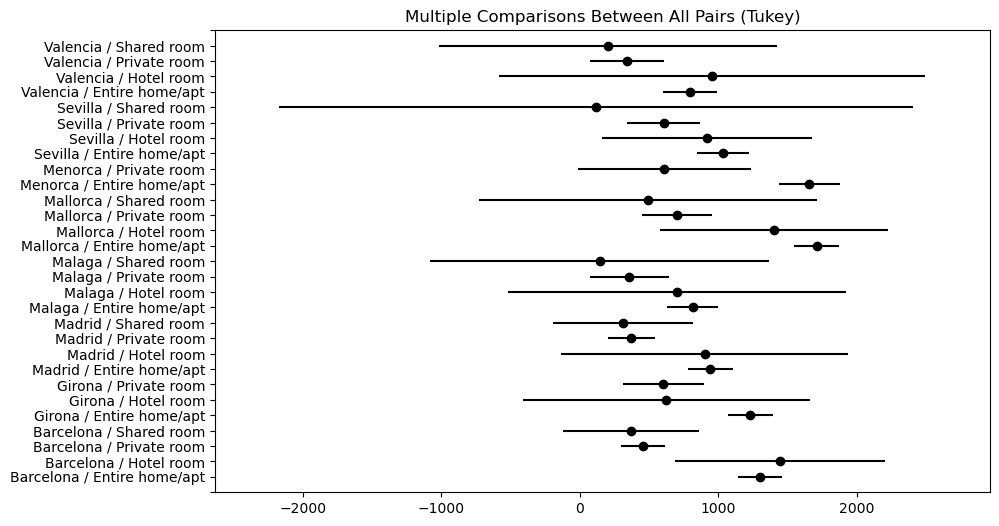

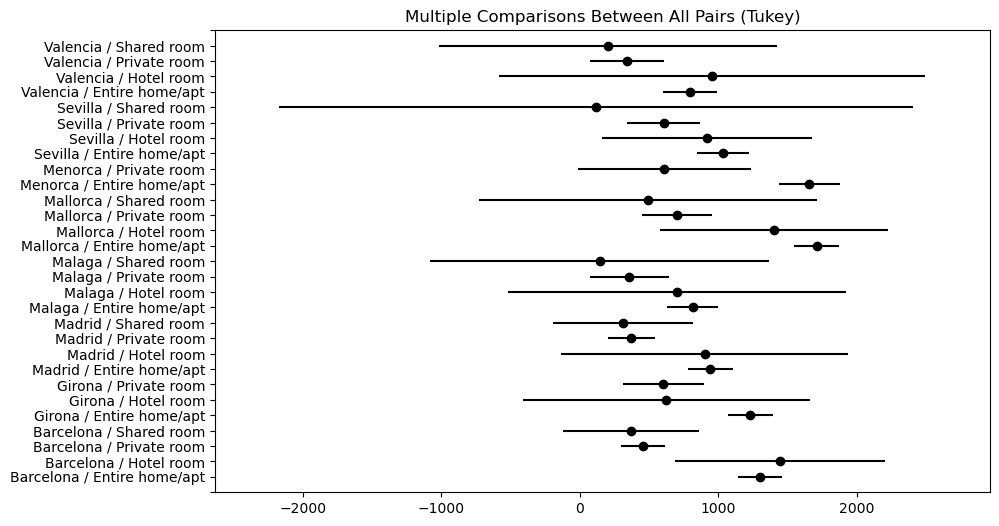

In [28]:
# Creamos una etiqueta combinada
df['combinacion'] = df['city'] + " / " + df['room_type']

# Hacemos el Tukey con esa nueva columna
tukey_total = pairwise_tukeyhsd(endog=df['price'], 
                                groups=df['combinacion'], 
                                alpha=0.05)

# Esto generará una tabla MUY larga, mejor graficarlo:
tukey_total.plot_simultaneous()

- El punto es la media estimada
- la línea es el margen de error
- como mas larga es la línea indica que hay mucha variedad de precios. 
- Las lineas mas largas se pueden dar tambien porque hay pocos datos (la mayoria de casos con Shared room y Hotel)


Mapa de distribución (se descarga en un archivo html)

In [29]:


# 1. Configuración de Coordenadas y Colores
ciudades_coords = {
    'Madrid': [40.4167, -3.7033], 'Barcelona': [41.3851, 2.1734],
    'Valencia': [39.4699, -0.3763], 'Sevilla': [37.3891, -5.9845],
    'Mallorca': [39.6953, 3.0176], 'Menorca': [39.9496, 4.1104],
    'Malaga': [36.7213, -4.4214], 'Girona': [41.9794, 2.8214]
}

colores_habitacion = {
    'Entire home/apt': '#3498db', 
    'Private room': '#9b59b6',
    'Hotel room': '#2ecc71', 
    'Shared room': '#f1c40f'
}

# 2. Crear el mapa base
m = folium.Map(location=[40.4167, -3.7033], zoom_start=6, tiles='CartoDB positron')

# 3. Añadir la LEYENDA (HTML Flotante que se guardará en el archivo)
leyenda_html = f'''
     <div style="position: fixed; 
     bottom: 50px; left: 50px; width: 180px; height: 120px; 
     background-color: white; border:2px solid grey; z-index:9999; font-size:12px;
     padding: 10px; border-radius: 5px; opacity: 0.9; font-family: Arial;">
     <b>Tipo de Habitación</b><br>
     <i style="background:{colores_habitacion['Entire home/apt']};width:12px;height:12px;display:inline-block;margin-right:5px;border-radius:2px;"></i> Apartamento/Casa<br>
     <i style="background:{colores_habitacion['Private room']};width:12px;height:12px;display:inline-block;margin-right:5px;border-radius:2px;"></i> Hab. Privada<br>
     <i style="background:{colores_habitacion['Hotel room']};width:12px;height:12px;display:inline-block;margin-right:5px;border-radius:2px;"></i> Hab. Hotel<br>
     <i style="background:{colores_habitacion['Shared room']};width:12px;height:12px;display:inline-block;margin-right:5px;border-radius:2px;"></i> Hab. Compartida<br>
     </div>
     '''
m.get_root().html.add_child(folium.Element(leyenda_html))



# 4. Generar los gráficos de tarta e insertarlos
for ciudad, coords in ciudades_coords.items():
    if ciudad in df['city'].unique():
        datos_ciudad = df[df['city'] == ciudad]['room_type'].value_counts()
        
        if not datos_ciudad.empty:
            # Crear tarta
            fig, ax = plt.subplots(figsize=(1.5, 1.5))
            colores_lista = [colores_habitacion.get(tipo, 'gray') for tipo in datos_ciudad.index]
            ax.pie(datos_ciudad, colors=colores_lista, startangle=90)
            ax.axis('equal')
            
            # Convertir a imagen base64
            buffer = io.BytesIO()
            plt.savefig(buffer, format='png', transparent=True, bbox_inches='tight', pad_inches=0)
            plt.close(fig)
            buffer.seek(0)
            img_str = base64.b64encode(buffer.read()).decode('utf-8')
            
            # Crear marcador con icono DivIcon
            html_icon = f'<img src="data:image/png;base64,{img_str}" style="width:50px;height:50px;">'
            folium.Marker(
                location=coords,
                icon=folium.DivIcon(html=html_icon, icon_size=(50, 50), icon_anchor=(25, 25)),
                popup=f"<b>{ciudad}</b><br>{datos_ciudad.to_string()}"
            ).add_to(m)

# 5. GUARDAR EL ARCHIVO
nombre_archivo = 'mapa_turismo_con_leyenda.html'
m.save(nombre_archivo)

print(f"¡Hecho! Busca el archivo '{nombre_archivo}' en tu carpeta y ábrelo con doble clic.")

ModuleNotFoundError: No module named 'folium'